## Pre-evaluation  

This modified script from evaluation.ipynb aims to check the produced `preprocessed_waveforms.h5` with the magnitude-distance bins indicated in the `experiments/config.py`.  

Objective: Adjustment of magnitude-distance bins so that the population is optimally distributed amongst all bins. It also checks if at least one bin is a null set.

In [1]:
import h5py
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt
from config import SpectrogramClassificationConfig
from matplotlib import rcParams
from tqdne.plot import BinPlot

d:\miniconda3\envs\tqdne\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = h5py.File("workdir/data/preprocessed_waveforms.h5", "r")

In [3]:
config = SpectrogramClassificationConfig("workdir")
mag_bins = config.mag_bins
dist_bins = config.dist_bins

# Matplotlib settings
rcParams["font.family"] = "serif"
rcParams["text.usetex"] = False
rcParams["font.size"] = 16

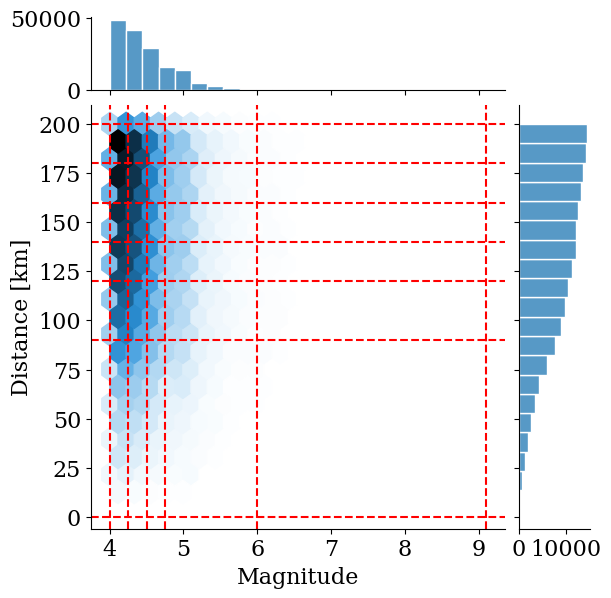

In [4]:
mag = np.concatenate([train.file["magnitude"][:]])
dist = np.concatenate([train.file["hypocentral_distance"][:]])
fig = sns.jointplot(
    x=mag,
    y=dist,
    kind="hex",
    marginal_ticks=True,
    joint_kws=dict(gridsize=20),
    marginal_kws=dict(bins=20, edgecolor="white"),
)
# plot.figure.set_size_inches([fig_width, fig_width])
plt.xlabel("Magnitude")
plt.ylabel("Distance [km]")

# draw bins
for x in mag_bins:
    plt.axvline(x, color="red", linestyle="--")
for y in dist_bins:
    plt.axhline(y, color="red", linestyle="--")

#fig.savefig("workdir/figures/binning.pdf")

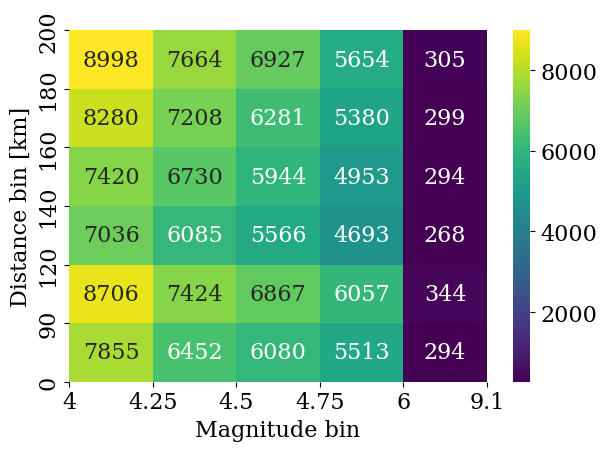

In [5]:
size_metric = lambda x, *args, **kwargs: len(x)
fig = BinPlot(metric=size_metric, mag_bins=mag_bins, dist_bins=dist_bins, fmt="d")(
    pred=mag, target=mag, mag=mag, dist=dist
)